## Modul 06 - Logika Fuzzy dan Sistem Inferensi Fuzzy

#### Instalasi scikit-fuzzy (±15 menit)

In [48]:
# 1. Instalasi library 
# !pip install scikit-fuzzy scipy networkx

# 2. Verifikasi import pustaka
import skfuzzy as fuzz
from skfuzzy import control as ctrl

#### Kegiatan 2 — Hitung Keanggotaan Manual (±45 menit)

In [8]:
def segitiga(x, a, b, c):
    """Derajat keanggotaan fungsi segitiga (a, b, c)."""
    if x <= a or x >= c:
        return 0.0 
    if x <= b:
        return (x - a) / (b - a) 
    return (c - x) / (c - b)  

suhu = 28
print("dingin :", segitiga(suhu, 0, 10, 25))
print("nyaman :", segitiga(suhu, 15, 25, 35))
print("panas :", segitiga(suhu, 25, 35, 45))

dingin : 0.0
nyaman : 0.7
panas : 0.3


Pengembangan 2

In [ ]:
def segitiga(x, a, b, c):
    """Derajat keanggotaan fungsi segitiga (a, b, c)."""
    if x <= a or x >= c:
        return 0.0 
    if x <= b:
        return (x - a) / (b - a)  
    return (c - x) / (c - b) 

suhu = 28
u_dingin = segitiga(suhu, 0, 10, 25)
u_nyaman = segitiga(suhu, 15, 25, 35)
u_panas = segitiga(suhu, 25, 35, 45)

# Menampilkan derajat keanggotaan suhu
print(f"Derajat Keanggotaan Suhu {suhu}°C")
print(f"dingin : {u_dingin:.1f}")
print(f"nyaman : {u_nyaman:.1f}")
print(f"panas  : {u_panas:.1f}")

# Uji variasi nilai suhu
print("\n\tUji Variasi Nilai Suhu")
print("Suhu | Dingin | Nyaman | Panas")
print("-" * 30)

for s in [20, 25, 28, 40]:
    d = segitiga(s, 0, 10, 25)
    n = segitiga(s, 15, 25, 35)
    p = segitiga(s, 25, 35, 45)
    print(f"{s:3d}°C | {d:6.1f} | {n:6.1f} | {p:5.1f}")

Derajat Keanggotaan Suhu 28°C
dingin : 0.0
nyaman : 0.7
panas  : 0.3

	Uji Variasi Nilai Suhu
Suhu | Dingin | Nyaman | Panas
------------------------------
 20°C |    0.3 |    0.5 |   0.0
 25°C |    0.0 |    1.0 |   0.0
 28°C |    0.0 |    0.7 |   0.3
 40°C |    0.0 |    0.0 |   0.5


#### Kegiatan 3 — Membangun FIS Kipas Otomatis (±80 menit)

> **Catatan:** Jangan lupa run kegiatan 1 untuk menginstall library.

Kecepatan kipas: 71.5%


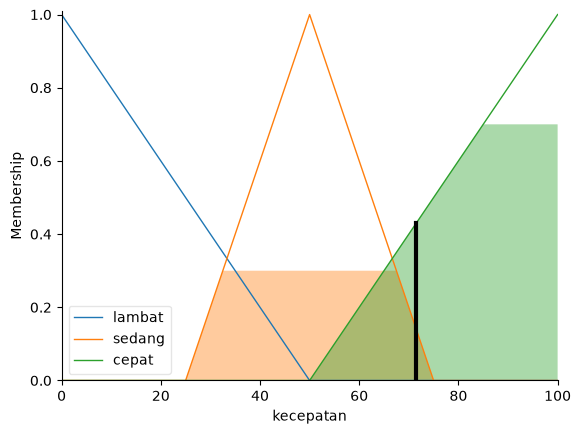

In [40]:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl

# 1) Definisikan variabel dan rentang semestanya
suhu = ctrl.Antecedent(np.arange(0, 46, 1), "suhu")
kelembapan = ctrl.Antecedent(np.arange(0, 101, 1), "kelembapan")
kecepatan = ctrl.Consequent(np.arange(0, 101, 1), "kecepatan")

# 2) Fungsi keanggotaan (angka sama dgn Kegiatan 2!)
suhu["dingin"] = fuzz.trimf(suhu.universe, [0, 10, 25])
suhu["nyaman"] = fuzz.trimf(suhu.universe, [15, 25, 35])
suhu["panas"] = fuzz.trimf(suhu.universe, [25, 35, 45])

kelembapan.automf(3, names=["kering", "normal", "tinggi"])

kecepatan["lambat"] = fuzz.trimf(kecepatan.universe, [0, 0, 50])
kecepatan["sedang"] = fuzz.trimf(kecepatan.universe, [25, 50, 75])
kecepatan["cepat"] = fuzz.trimf(kecepatan.universe, [50, 100, 100])

# 3) Basis aturan (terjemahan langsung dari Bagian A.3)
r1 = ctrl.Rule(suhu["dingin"], kecepatan["lambat"])
r2 = ctrl.Rule(suhu["nyaman"], kecepatan["sedang"])
r3 = ctrl.Rule(suhu["panas"] | kelembapan["tinggi"], kecepatan["cepat"])

# 4) Rangkai jadi sistem dan simulasikan
sistem = ctrl.ControlSystem([r1, r2, r3])
kipas = ctrl.ControlSystemSimulation(sistem)

kipas.input["suhu"] = 32
kipas.input["kelembapan"] = 75
kipas.compute()

print(f"Kecepatan kipas: {kipas.output['kecepatan']:.1f}%")
kecepatan.view(sim=kipas)

Pengembangan 3

PENGUJIAN INTERAKTIF KIPAS OTOMATIS

[HASIL]
Kecepatan kipas yang dihasilkan: 81.4%


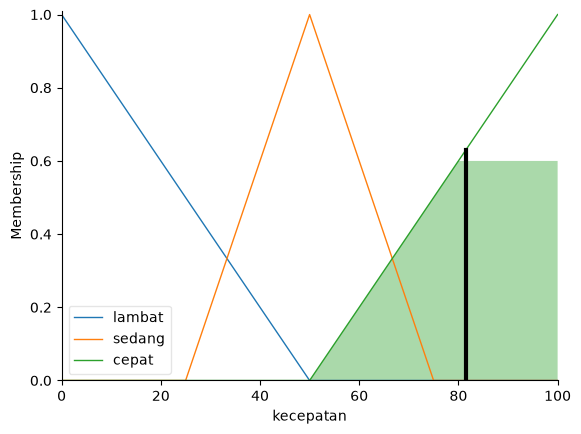

In [ ]:
print("PENGUJIAN INTERAKTIF KIPAS OTOMATIS")
val_suhu = float(input("Masukkan suhu (0 - 45 °C): "))
val_kelembapan = float(input("Masukkan kelembapan (0 - 100 %): "))
    
# Fuzzifikasi & Komputasi
kipas.input["suhu"] = val_suhu
kipas.input["kelembapan"] = val_kelembapan
kipas.compute()

# Tampilkan hasil
print(f"\n[HASIL]")
print(f"Kecepatan kipas yang dihasilkan: {kipas.output['kecepatan']:.1f}%")
kecepatan.view(sim=kipas)

#### Kegiatan 4 — Eksperimen Berbagai Input (±60 menit)

In [45]:
uji = [(16, 30), (20, 40), (28, 60), (32, 75), (38, 90)]

for s, k in uji:
    kipas.input["suhu"] = s
    kipas.input["kelembapan"] = k
    kipas.compute()
    print(f"suhu {s:2d}C lembap {k:3d}% -> kipas {kipas.output['kecepatan']:5.1f}%")

suhu 16C lembap  30% -> kipas  23.2%
suhu 20C lembap  40% -> kipas  37.9%
suhu 28C lembap  60% -> kipas  59.8%
suhu 32C lembap  75% -> kipas  71.5%
suhu 38C lembap  90% -> kipas  82.8%


Pengembangan 4

In [46]:
uji = [(16, 30), (20, 40), (28, 60), (32, 75), (38, 90)]

print(f"{'Suhu':^8} | {'Kelembapan':^12} | {'Kecepatan':^11} | {'Status':^10}")
print("-" * 48)

for s, k in uji:
    kipas.input["suhu"] = s
    kipas.input["kelembapan"] = k
    kipas.compute()
    kec = kipas.output["kecepatan"]

    if kec < 40:
        status = "Pelan"
    elif kec <= 70:
        status = "Sedang"
    else:
        status = "Kencang"

    print(f"{s:4d}°C   | {k:6d}%      | {kec:8.1f}%   | {status:^10}")

  Suhu   |  Kelembapan  |  Kecepatan  |   Status  
------------------------------------------------
  16°C   |     30%      |     23.2%   |   Pelan   
  20°C   |     40%      |     37.9%   |   Pelan   
  28°C   |     60%      |     59.8%   |   Sedang  
  32°C   |     75%      |     71.5%   |  Kencang  
  38°C   |     90%      |     82.8%   |  Kencang  


#### Kegiatan 5 — ✍ LATIHAN MANDIRI

##### Latihan 1 — Ubah perilaku: tambahkan label “sangat panas” (35, 45, 45) pada suhu dan aturan baru “JIKA sangat panas MAKA cepat”, lalu bandingkan output suhu 40° sebelum dan sesudahnya.

In [50]:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl

# 1. Definisi Variabel & Semesta
suhu = ctrl.Antecedent(np.arange(0, 46, 1), "suhu")
kelembapan = ctrl.Antecedent(np.arange(0, 101, 1), "kelembapan")
kecepatan = ctrl.Consequent(np.arange(0, 101, 1), "kecepatan")

# 2. Fungsi Keanggotaan Awal
suhu["dingin"] = fuzz.trimf(suhu.universe, [0, 10, 25])
suhu["nyaman"] = fuzz.trimf(suhu.universe, [15, 25, 35])
suhu["panas"] = fuzz.trimf(suhu.universe, [25, 35, 45])
kelembapan.automf(3, names=["kering", "normal", "tinggi"])

kecepatan["lambat"] = fuzz.trimf(kecepatan.universe, [0, 0, 50])
kecepatan["sedang"] = fuzz.trimf(kecepatan.universe, [25, 50, 75])
kecepatan["cepat"] = fuzz.trimf(kecepatan.universe, [50, 100, 100])

# 3. Basis Aturan Awal & Uji Suhu 40°C
aturan_awal = [
    ctrl.Rule(suhu["dingin"], kecepatan["lambat"]),
    ctrl.Rule(suhu["nyaman"], kecepatan["sedang"]),
    ctrl.Rule(suhu["panas"] | kelembapan["tinggi"], kecepatan["cepat"]),
]

sim = ctrl.ControlSystemSimulation(ctrl.ControlSystem(aturan_awal))
sim.inputs({"suhu": 40, "kelembapan": 75})
sim.compute()
hasil_sebelum = sim.output["kecepatan"]

# 4. Tambah Label & Aturan Baru 
suhu["sangat panas"] = fuzz.trimf(suhu.universe, [35, 45, 45])
aturan_baru = aturan_awal + [ctrl.Rule(suhu["sangat panas"], kecepatan["cepat"])]

sim = ctrl.ControlSystemSimulation(ctrl.ControlSystem(aturan_baru))
sim.inputs({"suhu": 40, "kelembapan": 75})
sim.compute()
hasil_sesudah = sim.output["kecepatan"]

# 5. Output Perbandingan
print(f"Kecepatan kipas SEBELUM ditambah aturan : {hasil_sebelum:.2f}%")
print(f"Kecepatan kipas SESUDAH ditambah aturan : {hasil_sesudah:.2f}%")

Kecepatan kipas SEBELUM ditambah aturan : 80.56%
Kecepatan kipas SESUDAH ditambah aturan : 80.56%


##### Latihan 2 — FIS kasus sendiri: bangun FIS lengkap untuk kasus pilihanmu (mis. lama penyiraman tanaman dari kelembapan tanah & suhu; atau besar tip dari rasa makanan & pelayanan): 2 input, 1 output, minimal 3 aturan, uji dengan 3 input berbeda.

In [52]:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl

# 1. Definisi Variabel Semesta
tanah = ctrl.Antecedent(np.arange(0, 101, 1), "tanah")
suhu = ctrl.Antecedent(np.arange(0, 51, 1), "suhu")
durasi = ctrl.Consequent(np.arange(0, 61, 1), "durasi")

# 2. Fungsi Keanggotaan
tanah["kering"] = fuzz.trimf(tanah.universe, [0, 0, 45])
tanah["normal"] = fuzz.trimf(tanah.universe, [30, 50, 70])
tanah["basah"] = fuzz.trimf(tanah.universe, [55, 100, 100])

suhu["sejuk"] = fuzz.trimf(suhu.universe, [0, 0, 25])
suhu["hangat"] = fuzz.trimf(suhu.universe, [20, 28, 36])
suhu["terik"] = fuzz.trimf(suhu.universe, [30, 50, 50])

durasi["sebentar"] = fuzz.trimf(durasi.universe, [0, 0, 25])
durasi["sedang"] = fuzz.trimf(durasi.universe, [15, 30, 45])
durasi["lama"] = fuzz.trimf(durasi.universe, [35, 60, 60])

# 3. Basis Aturan & Inisialisasi Sistem
aturan = [
    ctrl.Rule(tanah["kering"] | suhu["terik"], durasi["lama"]),
    ctrl.Rule(tanah["normal"] & suhu["hangat"], durasi["sedang"]),
    ctrl.Rule(tanah["basah"], durasi["sebentar"]),
]
siram = ctrl.ControlSystemSimulation(ctrl.ControlSystem(aturan))

# 4. Pengujian 3 Kasus Input Berbeda
uji = [
    {"kondisi": "Tanah Kering & Terik", "in": {"tanah": 15, "suhu": 38}},
    {"kondisi": "Tanah Normal & Hangat", "in": {"tanah": 50, "suhu": 27}},
    {"kondisi": "Tanah Basah & Sejuk", "in": {"tanah": 80, "suhu": 18}},
]

print("=== HASIL UJI SISTEM PENYIRAMAN TANAMAN ===")
for u in uji:
    siram.inputs(u["in"])
    siram.compute()
    print(f"- {u['kondisi']:<22} {u['in']} -> Durasi: {siram.output['durasi']:.1f} menit")

=== HASIL UJI SISTEM PENYIRAMAN TANAMAN ===
- Tanah Kering & Terik   {'tanah': 15, 'suhu': 38} -> Durasi: 51.0 menit
- Tanah Normal & Hangat  {'tanah': 50, 'suhu': 27} -> Durasi: 30.0 menit
- Tanah Basah & Sejuk    {'tanah': 80, 'suhu': 18} -> Durasi: 9.5 menit


##### Latihan 3 — Analisis (markdown): hitung manual keanggotaan salah satu input ujimu (seperti Kegiatan 2), lalu jelaskan minimal 3 kalimat mengapa fuzzy lebih cocok daripada if-else tegas untuk kasusmu.

### 1. Hitung Manual (Suhu 32°C, Kelembapan 75%) (Kegiatan 3 & 4)

Rumus Segitiga (a, b, c):
- Di luar batas = 0
- Sisi naik = (x - a) / (b - a)
- Sisi turun = (c - x) / (c - b)

Suhu (32°C):
- Dingin [0, 10, 25] = 0 (karena di atas 25)
- Nyaman [15, 25, 35] = sisi turun (35 - 32) / (35 - 25) = 3 / 10 = 0.3
- Panas [25, 35, 45] = sisi naik (32 - 25) / (35 - 25) = 7 / 10 = 0.7

Kelembapan (75%):
- Kering [0, 0, 50] = 0 (karena di atas 50)
- Normal [0, 50, 100] = sisi turun (100 - 75) / (100 - 50) = 25 / 50 = 0.5
- Tinggi [50, 100, 100] = sisi naik (75 - 50) / (100 - 50) = 25 / 50 = 0.5

### 2. Kenapa Pakai Fuzzy, Bukan IF-ELSE Kaku?

- Tidak ada lonjakan putaran kipas: Kalau pakai if-else, pada batas 30°C kipas bisa langsung mendadak berputar kencang dari posisi pelan, sedangkan fuzzy membuat percepatan motor kipas naik secara halus dan bertahap.
- Merefleksikan rasa nyaman manusia: Suhu 32°C terasa masih ada sisa nyamannya (0.3) sekaligus sudah mulai panas (0.7), sehingga fuzzy bisa membaca kondisi campuran tersebut.
- Lebih hemat energi: Kecepatan putaran kipas menyesuaikan kebutuhan secara proporsional, tidak melulu sakelar biner nyala maksimal atau mati total.

## Buku Ajar - Bab 05 Logika Fuzzy

#### **A. Pilihan Ganda**

#### 1. Derajat keanggotaan μ(x) bernilai pada rentang…
* [ ] (a) −1…1
* [x] **(b) 0…1**
* [ ] (c) 0…100
* [ ] (d) bebas

#### 2. Pada segitiga (10, 20, 30), μ untuk x = 25 adalah…
* [ ] (a) 0,25
* [x] **(b) 0,5**
* [ ] (c) 0,75
* [ ] (d) 1

#### 3. Operasi ATAU pada fuzzy memakai…
* [ ] (a) min
* [x] **(b) max**
* [ ] (c) perkalian
* [ ] (d) rata-rata

#### 4. Urutan empat tahap Mamdani yang benar:
* [ ] (a) agregasi–fuzzifikasi–evaluasi–defuzzifikasi
* [x] **(b) fuzzifikasi–evaluasi aturan–agregasi–defuzzifikasi**
* [ ] (c) evaluasi–defuzzifikasi–fuzzifikasi–agregasi
* [ ] (d) fuzzifikasi–defuzzifikasi–evaluasi–agregasi

#### 5. Dibanding Mamdani, keunggulan utama Sugeno adalah…
* [ ] (a) lebih akurat selalu
* [ ] (b) tidak butuh aturan
* [x] **(c) defuzzifikasi ringan (rata-rata berbobot) sehingga cepat untuk embedded**
* [ ] (d) tidak butuh fungsi keanggotaan

#### **B. Esai**

### 1. Rancang tiga fungsi keanggotaan (murah, sedang, mahal) untuk harga kos 0–1500 ribu rupiah — tuliskan titik-titiknya, gambarkan sketsanya, dan pastikan label bertetangga tumpang tindih. (Bandingkan dengan soal UAS take-home!)

Titik koordinat kurva:
* **Murah:** [0, 0, 600]
* **Sedang:** [400, 750, 1100]
* **Mahal:** [900, 1500, 1500]

Irisan / tumpang tindih:
* Murah & Sedang ketemu di rentang 400 – 600 ribu.
* Sedang & Mahal ketemu di rentang 900 – 1.100 ribu.

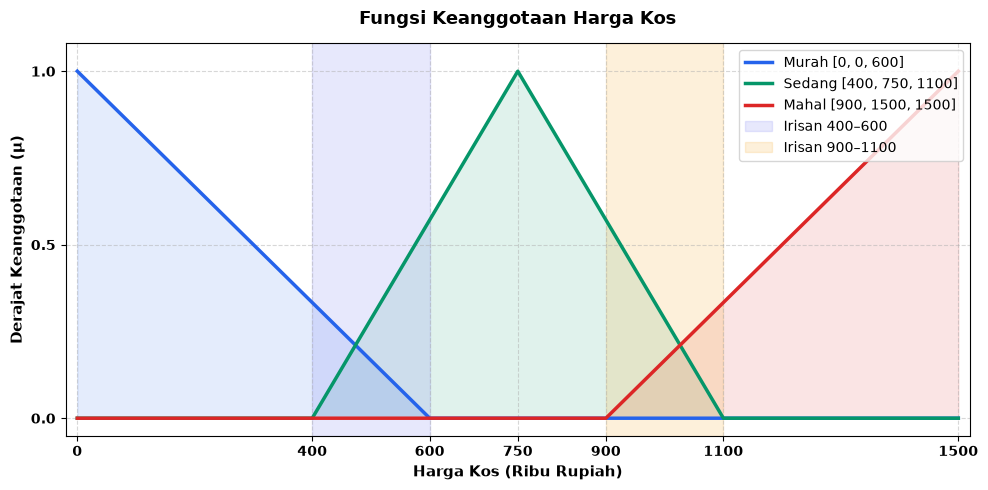

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Definisi semesta pembicaraan harga (0 - 1500 ribu Rp)
x = np.linspace(0, 1500, 1501)

# 2. Rumus fungsi keanggotaan (Murah, Sedang, Mahal)
mu_murah = np.clip((600 - x) / 600, 0, 1)

# Sedang: Segitiga [400, 750, 1100]
naik_sedang = (x - 400) / (750 - 400)
turun_sedang = (1100 - x) / (1100 - 750)
mu_sedang = np.clip(np.minimum(naik_sedang, turun_sedang), 0, 1)

# Mahal: Bahu kanan [900, 1500, 1500] -> naik dari 900 ke 1500
mu_mahal = np.clip((x - 900) / (1500 - 900), 0, 1)

# 3. Setup Plot
plt.figure(figsize=(10, 5))

plt.fill_between(x, mu_murah, color="#2563eb", alpha=0.12)
plt.fill_between(x, mu_sedang, color="#059669", alpha=0.12)
plt.fill_between(x, mu_mahal, color="#dc2626", alpha=0.12)

plt.plot(x, mu_murah, label="Murah [0, 0, 600]", color="#2563eb", linewidth=2.5)
plt.plot(x, mu_sedang, label="Sedang [400, 750, 1100]", color="#059669", linewidth=2.5)
plt.plot(x, mu_mahal, label="Mahal [900, 1500, 1500]", color="#dc2626", linewidth=2.5)

plt.axvspan(400, 600, color="#6366f1", alpha=0.15, label="Irisan 400–600")
plt.axvspan(900, 1100, color="#f59e0b", alpha=0.15, label="Irisan 900–1100")

# 4. Detail Tampilan
plt.title("Fungsi Keanggotaan Harga Kos", fontsize=13, fontweight="bold", pad=14)
plt.xlabel("Harga Kos (Ribu Rupiah)", fontsize=11, fontweight="bold")
plt.ylabel("Derajat Keanggotaan (μ)", fontsize=11, fontweight="bold")

plt.xticks([0, 400, 600, 750, 900, 1100, 1500], fontweight="bold")
plt.yticks([0.0, 0.5, 1.0], fontweight="bold")
plt.xlim(-20, 1520)
plt.ylim(-0.05, 1.08)

plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="upper right", frameon=True, fontsize=10)
plt.tight_layout()

# 5. Tampilkan
plt.show()

### 2. Dengan rancanganmu pada soal 1, hitung derajat ketiga label untuk harga 700 ribu dan 1.200 ribu.

**A. Harga 700 Ribu**
* Murah: 0
* Sedang: (700 - 400) / (750 - 400) = 300 / 350 ≈ **0,86**
* Mahal: 0

**B. Harga 1.200 Ribu**
* Murah: 0
* Sedang: 0
* Mahal: (1200 - 900) / (1500 - 900) = 300 / 600 = **0,5**

### 3. Kerjakan Mamdani mini: masukan tunggal “kebisingan kelas” μ tenang = 0,4 dan μ ribut = 0,6; aturan: tenang → volume pengeras 30, ribut → volume 80 (pakai Sugeno). Hitung volumenya, lalu jelaskan tiap langkahmu.

* Tenang (0,4) -> volume 30
* Ribut (0,6) -> volume 80

Hitungan:
Volume = ((0,4 x 30) + (0,6 x 80)) / (0,4 + 0,6)
Volume = (12 + 48) / 1,0 = **60**

Langkah:
1. Kalikan bobot dengan target volumenya (12 dan 48).
2. Jumlahkan total bobot (0,4 + 0,6 = 1,0).
3. Bagi hasil kali dengan total bobot (60 / 1,0 = 60).

### 4. Seorang praktikan membuat label suhu TANPA tumpang tindih: dingin (0,10,20), nyaman (20,25,30), panas (30,35,45). Analisis apa yang terjadi pada suhu tepat 20 °C dan 30 °C, dan mengapa desain ini buruk.

* Pada suhu pas 20 °C dan 30 °C, nilainya sama-sama **0**.
* **Kenapa jelek?**
  * Muncul dead zone (titik mati): tidak ada aturan yang jalan, sistem pendingin bisa bingung atau mati mendadak.
  * Sifat fuzzy hilang: transisi tidak halus lagi dan responnya jadi kaku seperti if-else biasa.

### 5. Bandingkan penanganan ketidakpastian certainty factor (Bab 4) dengan derajat keanggotaan
fuzzy: apa kesamaan rumus AND-nya, dan apa beda makna angkanya?

* **Sama di rumus AND:** Keduanya memakai nilai minimum (min) karena hasil keputusan dibatasi oleh syarat yang paling lemah[cite: 1].
* **Beda di arti angka:**
  * CF: Tingkat keyakinan subjektif fakta itu benar atau salah (-1 sampai +1)[cite: 1].
  * Fuzzy: Derajat keanggotaan fisik dalam kategori yang samar (0 sampai 1).